In [1]:
import pandas as pd
from statsmodels.stats.multitest import multipletests
from config import GRANGER_RESULTS

res_df = pd.read_parquet(GRANGER_RESULTS)

for test in ['sentiment_volume_z', 'sentiment_score_z']:
    g = res_df[res_df['test'] == test].copy()
    g['bh_reject'], g['p_adj'], *_ = multipletests(g['p_value'], alpha=0.05,
                                                   method='fdr_bh')[0:2] + (None, None)
    hits = g[g['bh_reject']].sort_values('p_adj')
    print(f"\n{test} - BH discoveries:")
    print(hits[['bb_tcm', 'ISIN', 'p_value', 'p_adj']].to_string(index=False))


sentiment_volume_z - BH discoveries:
 bb_tcm         ISIN      p_value        p_adj
SBNY US US82669G1040 1.017870e-20 1.414839e-17
FRCB US US33616C1009 1.399155e-09 9.724128e-07
AVNT US US73179P1066 1.438150e-05 6.663430e-03
ARMK US US03852U1060 4.986932e-05 1.616310e-02
 RYN US US7549071030 5.814063e-05 1.616310e-02
 GEO US US36162J1060 9.051828e-05 2.097007e-02
COLM US US1985161066 2.152664e-04 4.274575e-02

sentiment_score_z - BH discoveries:
 bb_tcm         ISIN  p_value    p_adj
RPAI US US76131V2025 0.000019 0.025884
  HI US US4315711089 0.000115 0.041965
MTDR US US5764852050 0.000121 0.041965
OTIS US US68902V1070 0.000089 0.041965


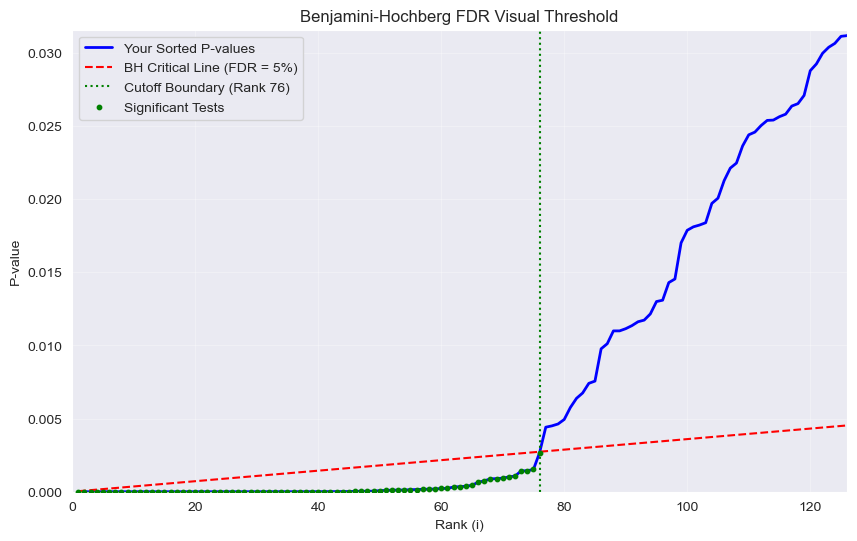

Total significant tests found: 76


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.multitest import multipletests

# 1. Simulate some dummy p-values for 1390 tests
np.random.seed(42)
# Mix of true effects (low p-values) and null effects (uniform distribution)
p_values = np.concatenate([np.random.beta(0.1, 10, 100), np.random.uniform(0, 1, 1290)])

# 2. Run the Benjamini-Hochberg correction
# 'fdr_bh' stands for False Discovery Rate Benjamini-Hochberg
significant, adjusted_p, _, _ = multipletests(p_values, alpha=0.05, method='fdr_bh')

# 3. Prepare data for the plot
m = len(p_values)
sorted_indices = np.argsort(p_values)
sorted_p = p_values[sorted_indices]
ranks = np.arange(1, m + 1)
bh_line = (ranks / m) * 0.05

# Find the highest significant rank boundary
sig_indices = np.where(sorted_p <= bh_line)[0]
max_sig_rank = sig_indices[-1] + 1 if len(sig_indices) > 0 else 0

# 4. Plot the results
plt.figure(figsize=(10, 6))
plt.plot(ranks, sorted_p, label='Your Sorted P-values', color='blue', linewidth=2)
plt.plot(ranks, bh_line, label='BH Critical Line (FDR = 5%)', color='red', linestyle='--')

if max_sig_rank > 0:
    plt.axvline(x=max_sig_rank, color='green', linestyle=':', label=f'Cutoff Boundary (Rank {max_sig_rank})')
    plt.scatter(ranks[:max_sig_rank], sorted_p[:max_sig_rank], color='green', s=10, zorder=5, label='Significant Tests')

plt.xlabel('Rank (i)')
plt.ylabel('P-value')
plt.title('Benjamini-Hochberg FDR Visual Threshold')
plt.xlim(0, max_sig_rank + 50) # Zoomed in near the threshold for clarity
plt.ylim(0, sorted_p[max_sig_rank + 50] if max_sig_rank + 50 < m else 0.1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Total significant tests found: {np.sum(significant)}")
